## 0. Instalasi & Import Library

In [1]:
!pip install scikit-fuzzy matplotlib seaborn scikit-learn pandas numpy -q


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\Falah\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.spatial.distance import cdist

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


## 1. Load Dataset

Upload kedua file CSV:
- `green_coffee_zeolite_drying_analytical_dataset.csv`
- `roasted_coffee_zeolite_drying_analytical_dataset.csv`

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
df_green = pd.read_csv('green_coffee_zeolite_drying_analytical_dataset.csv')
df_roast = pd.read_csv('roasted_coffee_zeolite_drying_analytical_dataset.csv')

print(f'Dataset Biji Kopi Hijau  : {df_green.shape[0]} baris x {df_green.shape[1]} kolom')
print(f'Dataset Biji Kopi Sangrai: {df_roast.shape[0]} baris x {df_roast.shape[1]} kolom')

Dataset Biji Kopi Hijau  : 54 baris x 15 kolom
Dataset Biji Kopi Sangrai: 54 baris x 13 kolom


## 2. Eksplorasi Dataset

In [ ]:
print('Statistik Deskriptif - Biji Kopi Hijau')
display(df_green.describe().round(4))

Statistik Deskriptif - Biji Kopi Hijau


,Total Phenolics (Folin–Ciocalteu),Total Phenolic Content (TPC; Solvent-Separated),Saponin Content (Solvent-Separated),Water Activity (aw),Reducing Sugars (DNS Method),Antioxidant Capacity (ABTS Assay),CIELab L* (Lightness),CIELab a* (Red–Green Axis),CIELab b* (Yellow–Blue Axis),CIELab Chroma (C*),CIELab Hue Angle (Source-Reported Scale),Bulk Density (kg/m³),pH,Moisture Content (%)
count,54.0000,54.0000,54.0000,54.0000,54.0000,54.0000,54.0000,54.0000,54.0000,54.0000,54.0000,54.0000,54.0000,54.0000
mean,53.0348,30.6644,215.7722,0.5052,8.4444,8985.7778,68.4756,2.5189,23.2483,25.7672,0.1072,749.5000,6.2283,10.6311
std,4.0009,9.3596,18.4462,0.0256,0.7992,382.3736,2.1293,0.6006,0.5522,1.1170,0.0237,31.7833,0.0476,0.1305
min,46.7520,20.9000,187.8000,0.4670,7.3000,8415.0000,64.2500,1.6300,22.1700,23.8000,0.0700,701.0000,6.1500,10.4300
25%,50.5600,21.3600,193.0000,0.4870,7.8000,8540.0000,67.0000,2.2000,22.9800,25.2700,0.0900,708.0000,6.1900,10.5200
50%,51.7025,27.7000,222.5000,0.5005,8.3500,9057.0000,69.0400,2.3950,23.1450,25.5400,0.1000,765.0000,6.2200,10.6350
75%,53.8240,42.7000,228.8000,0.5250,9.1000,9385.0000,70.3600,3.0500,23.5300,26.7900,0.1300,775.0000,6.2800,10.7300
max,63.5080,43.7000,239.0000,0.5490,9.7000,9435.0000,71.2200,3.7300,24.3900,28.1200,0.1500,781.0000,6.2900,10.8500


In [ ]:
print('Distribusi Kategori Perlakuan:')
display(df_green['Treatment Category'].value_counts())

Distribusi Kategori Perlakuan:


,count
Treatment Category,
Traditional drying without zeolite,9
Zeolite-assisted drying,9
Natural post-harvest process,6
Honey post-harvest process,6
Washed post-harvest process,6
Natural process without zeolite (NWZ),3
Honey process without zeolite (HWZ),3
Washed process without zeolite (WWZ),3
Natural process with zeolite-assisted drying (NWZ.),3


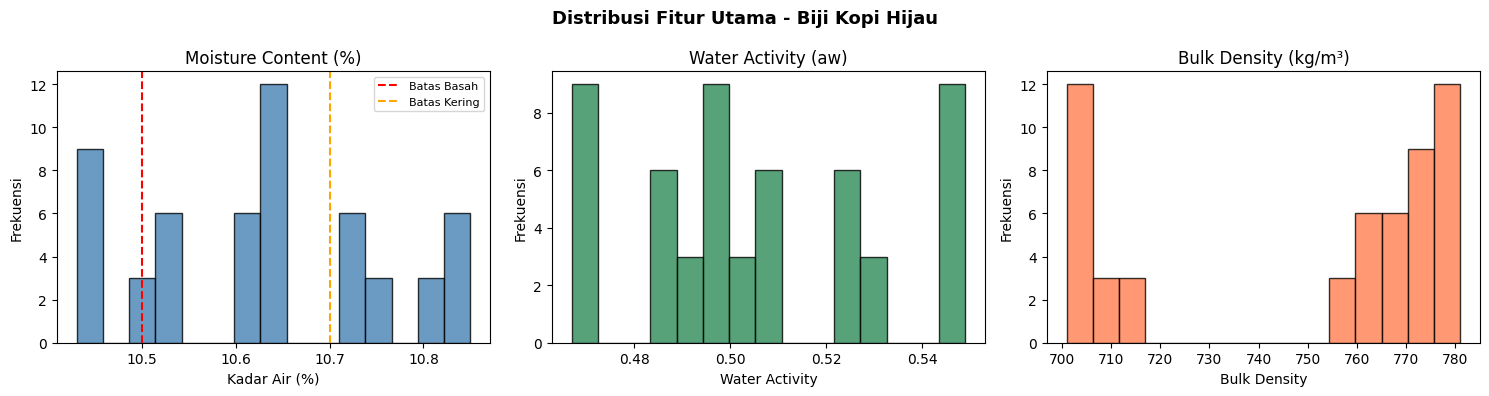

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribusi Fitur Utama - Biji Kopi Hijau', fontsize=13, fontweight='bold')

axes[0].hist(df_green['Moisture Content (%)'], bins=15, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(10.5, color='red', linestyle='--', label='Batas Basah')
axes[0].axvline(10.7, color='orange', linestyle='--', label='Batas Kering')
axes[0].set_title('Moisture Content (%)')
axes[0].set_xlabel('Kadar Air (%)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend(fontsize=8)

axes[1].hist(df_green['Water Activity (aw)'], bins=15, color='seagreen', edgecolor='black', alpha=0.8)
axes[1].set_title('Water Activity (aw)')
axes[1].set_xlabel('Water Activity')
axes[1].set_ylabel('Frekuensi')

axes[2].hist(df_green['Bulk Density (kg/m\u00b3)'], bins=15, color='coral', edgecolor='black', alpha=0.8)
axes[2].set_title('Bulk Density (kg/m\u00b3)')
axes[2].set_xlabel('Bulk Density')
axes[2].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('distribusi_fitur_utama.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing Data

Langkah preprocessing:
1. Pilih 11 fitur fisikokimia yang relevan sebagai input
2. Tangani missing values dengan nilai median
3. Normalisasi MinMaxScaler ke rentang [0, 1]

In [ ]:
FEATURES = [
    'Water Activity (aw)',
    'CIELab L* (Lightness)',
    'CIELab a* (Red\u2013Green Axis)',
    'CIELab b* (Yellow\u2013Blue Axis)',
    'CIELab Chroma (C*)',
    'Total Phenolics (Folin\u2013Ciocalteu)',
    'Saponin Content (Solvent-Separated)',
    'Antioxidant Capacity (ABTS Assay)',
    'Reducing Sugars (DNS Method)',
    'Bulk Density (kg/m\u00b3)',
    'pH'
]

TARGET = 'Moisture Content (%)'

X_raw = df_green[FEATURES].copy().fillna(df_green[FEATURES].median())
y_raw = df_green[TARGET].copy()

print('Cek Missing Values setelah imputasi:')
print(X_raw.isnull().sum().sum(), 'missing values')

Cek Missing Values setelah imputasi:
0 missing values


In [ ]:
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y_raw.values.reshape(-1, 1)).ravel()

print('Normalisasi selesai.')
print(f'Range X: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]')
print(f'Range y: [{y_scaled.min():.4f}, {y_scaled.max():.4f}]')

Normalisasi selesai.
Range X: [0.00, 1.00]
Range y: [0.0000, 1.0000]


## 4. Tahap 1 — Fuzzifikasi

Setiap fitur numerik ternormalisasi [0,1] diubah menjadi 3 nilai derajat keanggotaan menggunakan **fungsi keanggotaan triangular (trimf)**:

- **LOW** → rendah / basah
- **MEDIUM** → sedang / setengah kering
- **HIGH** → tinggi / kering

Nilai keanggotaan inilah yang akan menjadi fitur tambahan untuk Fuzzy K-Means.

In [ ]:
def trimf(x, a, b, c):
    #fungsi keanggotaan triangular
    left  = (x - a) / (b - a + 1e-10)
    right = (c - x) / (c - b + 1e-10)
    return np.clip(np.minimum(left, right), 0, 1)

def fuzzify(x_norm):
    #mengubah nilai ternormalisasi menjadi 3 nilai keanggotaan fuzzy
    mu_low    = trimf(x_norm, 0.0, 0.0, 0.5)
    mu_medium = trimf(x_norm, 0.0, 0.5, 1.0)
    mu_high   = trimf(x_norm, 0.5, 1.0, 1.0)
    return mu_low, mu_medium, mu_high

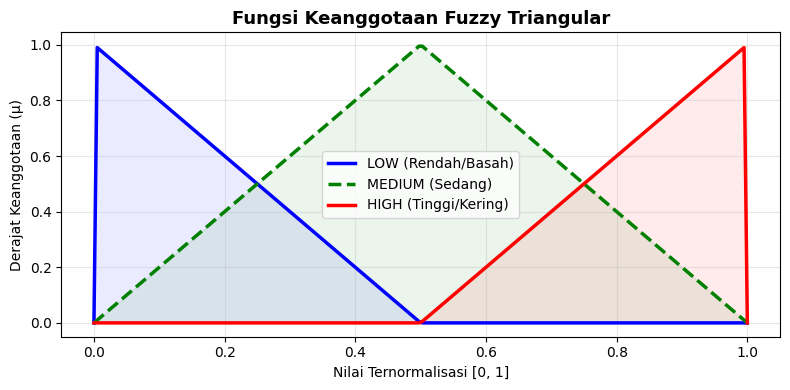

In [ ]:
x_demo = np.linspace(0, 1, 200)
mu_l, mu_m, mu_h = fuzzify(x_demo)

plt.figure(figsize=(8, 4))
plt.plot(x_demo, mu_l, 'b-',  linewidth=2.5, label='LOW (Rendah/Basah)')
plt.plot(x_demo, mu_m, 'g--', linewidth=2.5, label='MEDIUM (Sedang)')
plt.plot(x_demo, mu_h, 'r-',  linewidth=2.5, label='HIGH (Tinggi/Kering)')
plt.fill_between(x_demo, mu_l, alpha=0.08, color='blue')
plt.fill_between(x_demo, mu_m, alpha=0.08, color='green')
plt.fill_between(x_demo, mu_h, alpha=0.08, color='red')
plt.title('Fungsi Keanggotaan Fuzzy Triangular', fontsize=13, fontweight='bold')
plt.xlabel('Nilai Ternormalisasi [0, 1]')
plt.ylabel('Derajat Keanggotaan (\u03bc)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fungsi_keanggotaan_fuzzy.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#terapkan fuzzifikasi ke seluruh dataset, setiap fitur menghasilkan 3 nilai keanggotaan
fuzzy_data = {}
for feat in FEATURES:
    x_col = X_scaled_df[feat].values
    mu_l, mu_m, mu_h = fuzzify(x_col)
    short = feat.split('(')[0].strip().replace(' ', '_')[:18]
    fuzzy_data[f'mu_LOW_{short}']  = mu_l
    fuzzy_data[f'mu_MED_{short}']  = mu_m
    fuzzy_data[f'mu_HIGH_{short}'] = mu_h

df_fuzzy = pd.DataFrame(fuzzy_data)
print(f'Shape output fuzzy: {df_fuzzy.shape}')
print(f'({len(FEATURES)} fitur x 3 kategori = {df_fuzzy.shape[1]} kolom fuzzy)')

Shape output fuzzy: (54, 33)
(11 fitur x 3 kategori = 33 kolom fuzzy)


## 5. Tahap 2 — Fuzzy K-Means Clustering

Implementasi **Fuzzy C-Means (FCM)** dari scratch. Berbeda dengan K-Means biasa yang memberikan label tunggal, FCM memberikan **derajat keanggotaan** ke setiap klaster secara bersamaan.

**Rumus update keanggotaan:**
$$u_{ij} = \frac{1}{\sum_k \left(\frac{d_{ij}}{d_{kj}}\right)^{\frac{2}{m-1}}}$$

**Rumus update centroid:**
$$c_i = \frac{\sum_j u_{ij}^m \cdot x_j}{\sum_j u_{ij}^m}$$

Parameter:
- `n_clusters = 3` (Basah / Setengah Kering / Kering)
- `m = 2.0` (fuzziness coefficient)
- `max_iter = 200`, `tol = 1e-5`

In [ ]:
class FuzzyKMeans:

    def __init__(self, n_clusters=3, m=2.0, max_iter=200, tol=1e-5, random_state=42):
        self.n_clusters    = n_clusters
        self.m             = m
        self.max_iter      = max_iter
        self.tol           = tol
        self.random_state  = random_state
        self.centers_      = None
        self.membership_   = None
        self.history_      = []

    def _init_membership(self, n_samples):
        rng = np.random.RandomState(self.random_state)
        return rng.dirichlet(np.ones(self.n_clusters), size=n_samples)

    def _update_centers(self, X, U):
        Um = U ** self.m
        return (Um.T @ X) / Um.T.sum(axis=1, keepdims=True)

    def _update_membership(self, X, centers):
        D = np.fmax(cdist(X, centers, metric='euclidean'), 1e-10)
        D_exp = D ** (2.0 / (self.m - 1))
        return 1.0 / (D_exp * (1.0 / D_exp).sum(axis=1, keepdims=True))

    def _objective(self, X, U, centers):
        D = cdist(X, centers, metric='sqeuclidean')
        return np.sum((U ** self.m) * D)

    def fit(self, X):
        U = self._init_membership(X.shape[0])
        centers = self._update_centers(X, U)
        for i in range(self.max_iter):
            U_old   = U.copy()
            centers = self._update_centers(X, U)
            U       = self._update_membership(X, centers)
            self.history_.append(self._objective(X, U, centers))
            if np.linalg.norm(U - U_old) < self.tol:
                print(f'Konvergen pada iterasi ke-{i+1}')
                break
        self.centers_   = centers
        self.membership_ = U
        return self

    def predict(self, X=None):
        if X is None:
            return np.argmax(self.membership_, axis=1)
        return np.argmax(self._update_membership(X, self.centers_), axis=1)

    def get_membership(self, X=None):
        if X is None:
            return self.membership_
        return self._update_membership(X, self.centers_)

print('Class FuzzyKMeans siap.')

Class FuzzyKMeans siap.


In [ ]:
#fitur yang dipakai untuk clustering: fitur asli + nilai fuzzy Water Activity dan Bulk Density
CLUSTER_FEATURES = ['Water Activity (aw)', 'CIELab L* (Lightness)', 'Bulk Density (kg/m\u00b3)', 'pH']

wa_col = X_scaled_df['Water Activity (aw)'].values
bd_col = X_scaled_df['Bulk Density (kg/m\u00b3)'].values

mu_l_wa, mu_m_wa, mu_h_wa = fuzzify(wa_col)
mu_l_bd, mu_m_bd, mu_h_bd = fuzzify(bd_col)

X_for_cluster = np.column_stack([
    X_scaled_df[CLUSTER_FEATURES].values,
    mu_l_wa, mu_m_wa, mu_h_wa,
    mu_l_bd, mu_m_bd, mu_h_bd
])

print(f'Shape input clustering: {X_for_cluster.shape}')

Shape input clustering: (54, 10)


In [ ]:
print('Melatih Fuzzy K-Means...')
fkm = FuzzyKMeans(n_clusters=3, m=2.0, max_iter=200, tol=1e-5, random_state=42)
fkm.fit(X_for_cluster)

cluster_labels_raw = fkm.predict()
U_membership       = fkm.get_membership()

print(f'Distribusi klaster: {np.bincount(cluster_labels_raw)}')

Melatih Fuzzy K-Means...
Konvergen pada iterasi ke-23
Distribusi klaster: [18 18 18]


In [ ]:
#interpretasi klaster berdasarkan rata-rata Moisture Content
df_temp = df_green.copy()
df_temp['Cluster_Raw'] = cluster_labels_raw
cluster_mc_mean = df_temp.groupby('Cluster_Raw')[TARGET].mean().sort_values()

sorted_clusters = cluster_mc_mean.index.tolist()
cluster_name_map = {
    sorted_clusters[0]: 'Kering',
    sorted_clusters[1]: 'Setengah Kering',
    sorted_clusters[2]: 'Basah'
}

cluster_labels_named = np.array([cluster_name_map[c] for c in cluster_labels_raw])

print('Rata-rata Moisture Content per klaster:')
print(cluster_mc_mean.round(4))
print()
print('Mapping klaster:')
for k, v in cluster_name_map.items():
    print(f'  Klaster {k} -> {v}')
print()
print('Distribusi label:')
print(pd.Series(cluster_labels_named).value_counts())

Rata-rata Moisture Content per klaster:
Cluster_Raw
2    10.5333
0    10.6250
1    10.7350
Name: Moisture Content (%), dtype: float64

Mapping klaster:
  Klaster 2 -> Kering
  Klaster 0 -> Setengah Kering
  Klaster 1 -> Basah

Distribusi label:
Basah              18
Setengah Kering    18
Kering             18
Name: count, dtype: int64


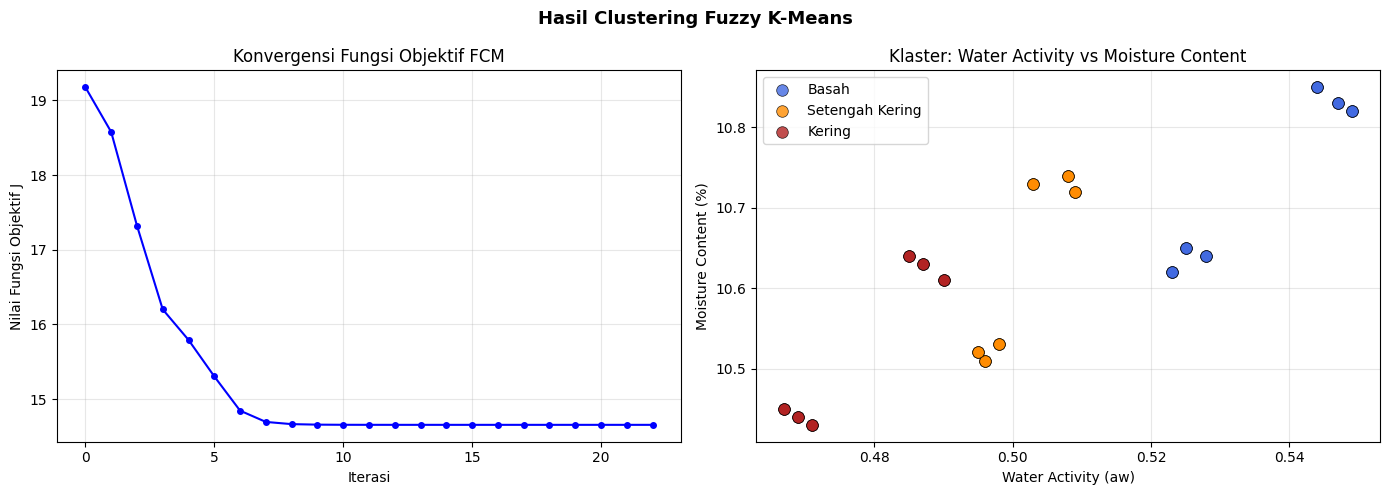

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hasil Clustering Fuzzy K-Means', fontsize=13, fontweight='bold')

axes[0].plot(fkm.history_, 'b-o', markersize=4, linewidth=1.5)
axes[0].set_title('Konvergensi Fungsi Objektif FCM')
axes[0].set_xlabel('Iterasi')
axes[0].set_ylabel('Nilai Fungsi Objektif J')
axes[0].grid(alpha=0.3)

color_map = {'Basah': 'royalblue', 'Setengah Kering': 'darkorange', 'Kering': 'firebrick'}
for label, color in color_map.items():
    mask = cluster_labels_named == label
    axes[1].scatter(
        df_green.loc[mask, 'Water Activity (aw)'],
        df_green.loc[mask, TARGET],
        c=color, label=label, s=70, alpha=0.8, edgecolors='black', linewidths=0.5
    )
axes[1].set_title('Klaster: Water Activity vs Moisture Content')
axes[1].set_xlabel('Water Activity (aw)')
axes[1].set_ylabel('Moisture Content (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('hasil_fuzzy_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

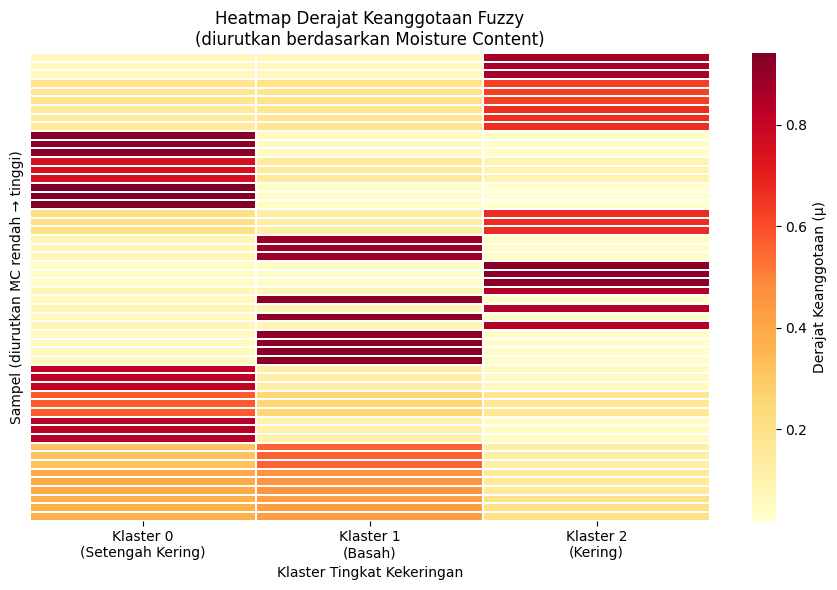

In [ ]:
#heatmap derajat keanggotaan fuzzy, diurutkan berdasarkan Moisture Content
sort_idx    = df_green[TARGET].argsort().values
U_sorted    = U_membership[sort_idx]
heatmap_cols = [f'Klaster {i}\n({cluster_name_map[i]})' for i in range(3)]

plt.figure(figsize=(9, 6))
sns.heatmap(
    U_sorted,
    cmap='YlOrRd',
    xticklabels=heatmap_cols,
    yticklabels=False,
    cbar_kws={'label': 'Derajat Keanggotaan (\u03bc)'},
    linewidths=0.1
)
plt.title('Heatmap Derajat Keanggotaan Fuzzy\n(diurutkan berdasarkan Moisture Content)', fontsize=12)
plt.xlabel('Klaster Tingkat Kekeringan')
plt.ylabel('Sampel (diurutkan MC rendah \u2192 tinggi)')
plt.tight_layout()
plt.savefig('heatmap_keanggotaan_fuzzy.png', dpi=150, bbox_inches='tight')
plt.show()

### Evaluasi Kualitas Klasterisasi: Partition Coefficient (FC) & Partition Entropy (HC)

Dua indeks validasi internal yang umum digunakan untuk Fuzzy C-Means:

- **FC (Partition Coefficient)** → mengukur seberapa besar derajat keanggotaan terkonsentrasi ke satu klaster. Nilai mendekati 1 berarti klasterisasi bersih (hampir *hard*), nilai mendekati 1/c berarti sangat overlapping.
$$FC = \\frac{1}{N} \\sum_{k=1}^{N} \\sum_{i=1}^{c} u_{ik}^2$$

- **HC (Partition Entropy)** → mengukur ketidakpastian/ambiguitas keanggotaan. Nilai mendekati 0 berarti klasterisasi tegas, nilai mendekati log(c) berarti sangat ambigu.
$$HC = -\\frac{1}{N} \\sum_{k=1}^{N} \\sum_{i=1}^{c} u_{ik} \\log(u_{ik})$$

In [ ]:
def partition_coefficient(U):
    # FC: rata-rata kuadrat derajat keanggotaan, range [1/c, 1]
    return np.mean(np.sum(U ** 2, axis=1))

def partition_entropy(U):
    # HC: rata-rata entropi derajat keanggotaan, range [0, log(c)]
    U_safe = np.clip(U, 1e-10, 1.0)
    return -np.mean(np.sum(U_safe * np.log(U_safe), axis=1))

fc_val = partition_coefficient(U_membership)
hc_val = partition_entropy(U_membership)
n_clusters = fkm.n_clusters

print('Evaluasi Kualitas Klasterisasi Fuzzy K-Means (Green Coffee)')
print(f'  Partition Coefficient (FC) : {fc_val:.6f}  (ideal -> 1.0, minimum = {1/n_clusters:.4f})')
print(f'  Partition Entropy     (HC) : {hc_val:.6f}  (ideal -> 0.0, maksimum = {np.log(n_clusters):.4f})')
print()
print(f'  Interpretasi:')
print(f'    FC = {fc_val:.4f} -> ', end='')
if fc_val >= 0.7:
    print('Klasterisasi BAIK (derajat keanggotaan cukup tegas)')
elif fc_val >= 0.5:
    print('Klasterisasi CUKUP (ada overlap antar klaster)')
else:
    print('Klasterisasi LEMAH (sangat overlapping)')

print(f'    HC = {hc_val:.4f} -> ', end='')
if hc_val <= 0.5:
    print('Entropi RENDAH (ambiguitas keanggotaan kecil)')
elif hc_val <= 1.0:
    print('Entropi SEDANG')
else:
    print('Entropi TINGGI (banyak sampel ambigu)')


Evaluasi Kualitas Klasterisasi Fuzzy K-Means (Green Coffee)
  Partition Coefficient (FC) : 0.644376  (ideal -> 1.0, minimum = 0.3333)
  Partition Entropy     (HC) : 0.643028  (ideal -> 0.0, maksimum = 1.0986)

  Interpretasi:
    FC = 0.6444 -> Klasterisasi CUKUP (ada overlap antar klaster)
    HC = 0.6430 -> Entropi SEDANG


## 6. Tahap 3 — Multi-Layer Perceptron (MLP)

### Konsep Stacking

Output dari Fuzzy K-Means (derajat keanggotaan + label klaster) dijadikan **fitur tambahan** untuk MLP. Total input MLP:

| Sumber | Jumlah Fitur |
|---|---|
| Fitur fisikokimia ternormalisasi | 11 |
| Derajat keanggotaan Fuzzy K-Means | 3 |
| One-hot label klaster | 3 |
| **Total** | **17** |

### Arsitektur MLP
```
Input(17) → Dense(64, ReLU) → Dense(32, ReLU) → Dense(16, ReLU) → Output(1)
```
Optimizer: Adam | Learning Rate: 0.001 (adaptive)

In [ ]:
#one-hot encode label klaster keras
ohe = OneHotEncoder(sparse_output=False)
cluster_onehot = ohe.fit_transform(cluster_labels_raw.reshape(-1, 1))

#gabungkan semua fitur untuk input MLP
X_mlp = np.hstack([X_scaled, U_membership, cluster_onehot])

print(f'Total fitur input MLP: {X_mlp.shape[1]}')
print(f'  - Fisikokimia     : {X_scaled.shape[1]}')
print(f'  - Keanggotaan FCM : {U_membership.shape[1]}')
print(f'  - One-hot klaster : {cluster_onehot.shape[1]}')

Total fitur input MLP: 17
  - Fisikokimia     : 11
  - Keanggotaan FCM : 3
  - One-hot klaster : 3


In [ ]:
#split 70% train, 15% validasi, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(X_mlp, y_scaled, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15/(1-0.15), random_state=42)

print(f'Training   : {X_train.shape[0]} sampel')
print(f'Validation : {X_val.shape[0]} sampel')
print(f'Testing    : {X_test.shape[0]} sampel')

Training   : 37 sampel
Validation : 8 sampel
Testing    : 9 sampel


In [ ]:
print('Melatih MLP...')

mlp_model = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    learning_rate='adaptive',
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    random_state=42,
    verbose=False
)

mlp_model.fit(X_train, y_train)

print(f'Pelatihan selesai: {mlp_model.n_iter_} iterasi, loss akhir: {mlp_model.loss_:.6f}')

Melatih MLP...
Pelatihan selesai: 254 iterasi, loss akhir: 0.000126


## 7. Evaluasi Model

In [ ]:
def evaluate_mlp(model, X, y_norm, scaler_y, nama_set):
    y_pred_norm = model.predict(X)
    y_pred = scaler_y.inverse_transform(y_pred_norm.reshape(-1, 1)).ravel()
    y_true = scaler_y.inverse_transform(y_norm.reshape(-1, 1)).ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f'--- {nama_set} ---')
    print(f'  RMSE : {rmse:.6f} %')
    print(f'  MAE  : {mae:.6f} %')
    print(f'  MAPE : {mape:.4f} %')
    print(f'  R2   : {r2:.4f}')

    return y_pred, y_true, {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

y_pred_train, y_true_train, m_train = evaluate_mlp(mlp_model, X_train, y_train, scaler_y, 'Training')
y_pred_val,   y_true_val,   m_val   = evaluate_mlp(mlp_model, X_val,   y_val,   scaler_y, 'Validation')
y_pred_test,  y_true_test,  m_test  = evaluate_mlp(mlp_model, X_test,  y_test,  scaler_y, 'Test')

--- Training ---
  RMSE : 0.002212 %
  MAE  : 0.000890 %
  MAPE : 0.0085 %
  R2   : 0.9997
--- Validation ---
  RMSE : 0.005584 %
  MAE  : 0.003158 %
  MAPE : 0.0302 %
  R2   : 0.9982
--- Test ---
  RMSE : 0.001722 %
  MAE  : 0.000977 %
  MAPE : 0.0093 %
  R2   : 0.9998


In [ ]:
metrics_df = pd.DataFrame({
    'Metrik'     : ['RMSE (%)', 'MAE (%)', 'MAPE (%)', 'R2'],
    'Training'   : [m_train['RMSE'], m_train['MAE'], m_train['MAPE'], m_train['R2']],
    'Validation' : [m_val['RMSE'],   m_val['MAE'],   m_val['MAPE'],   m_val['R2']],
    'Test'       : [m_test['RMSE'],  m_test['MAE'],  m_test['MAPE'],  m_test['R2']]
}).set_index('Metrik').round(6)

print('Ringkasan Metrik Evaluasi MLP:')
display(metrics_df)

Ringkasan Metrik Evaluasi MLP:


,Training,Validation,Test
Metrik,,,
RMSE (%),0.002212,0.005584,0.001722
MAE (%),0.000890,0.003158,0.000977
MAPE (%),0.008481,0.030161,0.009335
R2,0.999685,0.998163,0.999842


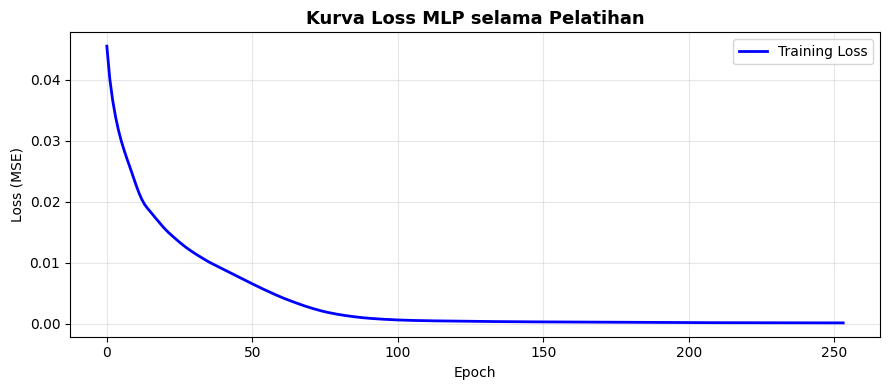

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(mlp_model.loss_curve_, 'b-', linewidth=2, label='Training Loss')
plt.title('Kurva Loss MLP selama Pelatihan', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve_mlp.png', dpi=150, bbox_inches='tight')
plt.show()

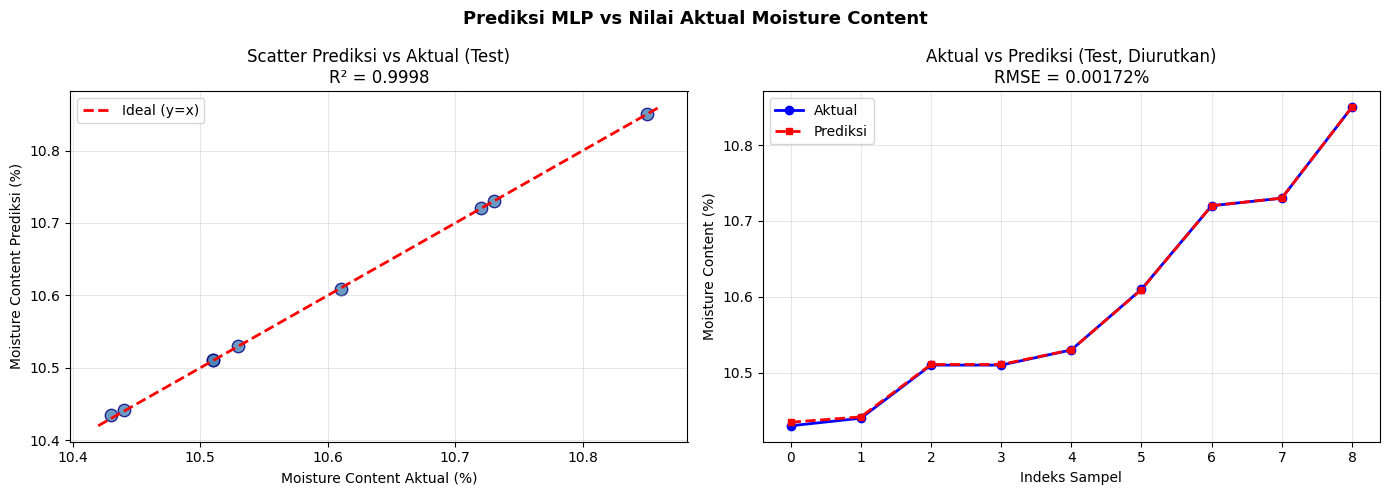

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prediksi MLP vs Nilai Aktual Moisture Content', fontsize=13, fontweight='bold')

axes[0].scatter(y_true_test, y_pred_test, color='steelblue', alpha=0.8, edgecolors='navy', s=80)
min_v = min(y_true_test.min(), y_pred_test.min()) - 0.01
max_v = max(y_true_test.max(), y_pred_test.max()) + 0.01
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Ideal (y=x)')
axes[0].set_title(f'Scatter Prediksi vs Aktual (Test)\nR\u00b2 = {m_test["R2"]:.4f}')
axes[0].set_xlabel('Moisture Content Aktual (%)')
axes[0].set_ylabel('Moisture Content Prediksi (%)')
axes[0].legend()
axes[0].grid(alpha=0.3)

idx_sort = np.argsort(y_true_test)
axes[1].plot(range(len(y_true_test)), y_true_test[idx_sort], 'b-o', markersize=6, linewidth=2, label='Aktual')
axes[1].plot(range(len(y_pred_test)), y_pred_test[idx_sort], 'r--s', markersize=5, linewidth=2, label='Prediksi')
axes[1].set_title(f'Aktual vs Prediksi (Test, Diurutkan)\nRMSE = {m_test["RMSE"]:.5f}%')
axes[1].set_xlabel('Indeks Sampel')
axes[1].set_ylabel('Moisture Content (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('prediksi_vs_aktual.png', dpi=150, bbox_inches='tight')
plt.show()

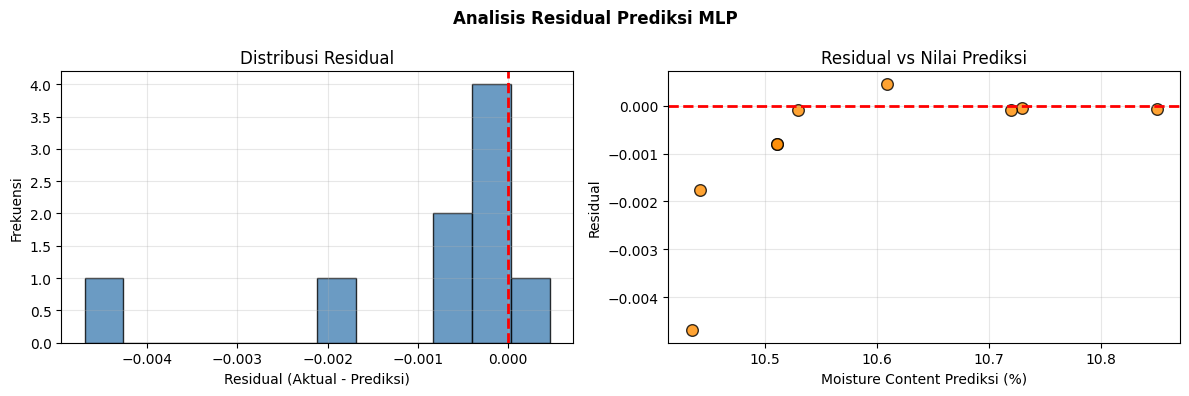

In [ ]:
residuals = y_true_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Analisis Residual Prediksi MLP', fontsize=12, fontweight='bold')

axes[0].hist(residuals, bins=12, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Distribusi Residual')
axes[0].set_xlabel('Residual (Aktual - Prediksi)')
axes[0].set_ylabel('Frekuensi')
axes[0].grid(alpha=0.3)

axes[1].scatter(y_pred_test, residuals, color='darkorange', alpha=0.8, edgecolors='black', s=70)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residual vs Nilai Prediksi')
axes[1].set_xlabel('Moisture Content Prediksi (%)')
axes[1].set_ylabel('Residual')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('analisis_residual.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Ablation Study: MLP Biasa vs Hybrid Fuzzy K-Means + MLP

Untuk membuktikan kontribusi Fuzzy K-Means, dilakukan perbandingan:
- **Baseline**: MLP dengan hanya fitur fisikokimia (11 fitur)
- **Hybrid**: MLP dengan fitur fisikokimia + output Fuzzy K-Means (17 fitur)

In [ ]:
X_pl_temp, X_pl_test, y_pl_temp, y_pl_test = train_test_split(X_scaled, y_scaled, test_size=0.15, random_state=42)
X_pl_train, X_pl_val, y_pl_train, y_pl_val = train_test_split(X_pl_temp, y_pl_temp, test_size=0.15/(1-0.15), random_state=42)

print('Melatih MLP Baseline...')
mlp_baseline = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    learning_rate='adaptive',
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    random_state=42,
    verbose=False
)
mlp_baseline.fit(X_pl_train, y_pl_train)

y_pred_bl  = mlp_baseline.predict(X_pl_test)
y_pred_bl  = scaler_y.inverse_transform(y_pred_bl.reshape(-1, 1)).ravel()
y_true_bl  = scaler_y.inverse_transform(y_pl_test.reshape(-1, 1)).ravel()

rmse_bl = np.sqrt(mean_squared_error(y_true_bl, y_pred_bl))
mae_bl  = mean_absolute_error(y_true_bl, y_pred_bl)
mape_bl = np.mean(np.abs((y_true_bl - y_pred_bl) / y_true_bl)) * 100
r2_bl   = r2_score(y_true_bl, y_pred_bl)

print(f'Baseline selesai ({mlp_baseline.n_iter_} iterasi)')

Melatih MLP Baseline...
Baseline selesai (226 iterasi)


In [ ]:
comparison = pd.DataFrame({
    'Model'         : ['MLP Biasa (Baseline)', 'Hybrid Fuzzy K-Means + MLP'],
    'Input Fitur'   : [len(FEATURES), X_mlp.shape[1]],
    'RMSE (%)'      : [rmse_bl, m_test['RMSE']],
    'MAE (%)'       : [mae_bl,  m_test['MAE']],
    'MAPE (%)'      : [mape_bl, m_test['MAPE']],
    'R2 Score'      : [r2_bl,   m_test['R2']]
}).set_index('Model').round(6)

print('Perbandingan Performa: Baseline vs Hybrid')
display(comparison)

print(f'\nPeningkatan RMSE: {(rmse_bl - m_test["RMSE"]) / rmse_bl * 100:+.2f}%')
print(f'Peningkatan R2  : {m_test["R2"] - r2_bl:+.4f}')

Perbandingan Performa: Baseline vs Hybrid


,Input Fitur,RMSE (%),MAE (%),MAPE (%),R2 Score
Model,,,,,
MLP Biasa (Baseline),11,0.007351,0.004646,0.043528,0.997122
Hybrid Fuzzy K-Means + MLP,17,0.001722,0.000977,0.009335,0.999842



Peningkatan RMSE: +76.58%
Peningkatan R2  : +0.0027


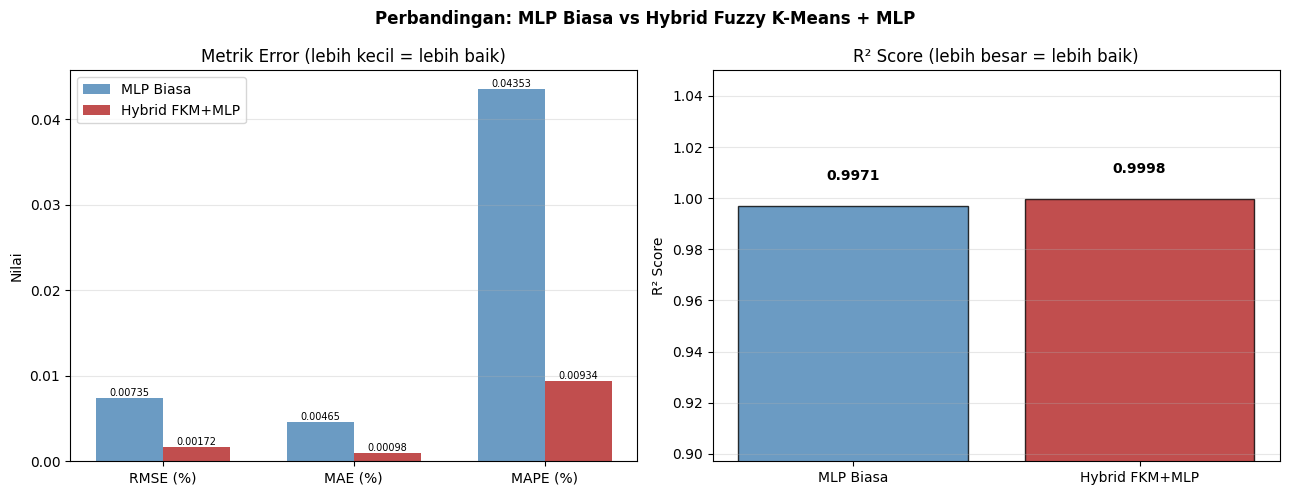

In [ ]:
metrics_names = ['RMSE (%)', 'MAE (%)', 'MAPE (%)']
vals_bl     = [rmse_bl, mae_bl, mape_bl]
vals_hybrid = [m_test['RMSE'], m_test['MAE'], m_test['MAPE']]

x     = np.arange(len(metrics_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Perbandingan: MLP Biasa vs Hybrid Fuzzy K-Means + MLP', fontsize=12, fontweight='bold')

bars1 = axes[0].bar(x - width/2, vals_bl,     width, label='MLP Biasa',      color='steelblue', alpha=0.8)
bars2 = axes[0].bar(x + width/2, vals_hybrid, width, label='Hybrid FKM+MLP', color='firebrick',  alpha=0.8)
axes[0].set_title('Metrik Error (lebih kecil = lebih baik)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names)
axes[0].set_ylabel('Nilai')
axes[0].legend()
axes[0].bar_label(bars1, fmt='%.5f', fontsize=7)
axes[0].bar_label(bars2, fmt='%.5f', fontsize=7)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(['MLP Biasa', 'Hybrid FKM+MLP'], [r2_bl, m_test['R2']],
            color=['steelblue', 'firebrick'], alpha=0.8, edgecolor='black')
axes[1].set_title('R\u00b2 Score (lebih besar = lebih baik)')
axes[1].set_ylabel('R\u00b2 Score')
axes[1].set_ylim([min(r2_bl, m_test['R2']) - 0.1, 1.05])
for i, v in enumerate([r2_bl, m_test['R2']]):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('perbandingan_baseline_hybrid.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Evaluasi Lengkap: Green Coffee vs Roasted Coffee

Bagian ini mengevaluasi performa sistem hybrid pada **kedua dataset** secara penuh:

1. Preprocessing & fuzzifikasi khusus roasted coffee
2. Fuzzy K-Means pada roasted coffee (model baru) + hitung FC & HC
3. MLP pada roasted coffee (menggunakan `Moisture Content (%)` sebagai target)
4. Perbandingan metrik evaluasi Green vs Roasted side-by-side

In [ ]:
FEATURES_ROAST = [
    'Water Activity (aw)',
    'CIELab L* (Lightness)',
    'CIELab a* (Red–Green Axis)',
    'CIELab b* (Yellow–Blue Axis)',
    'CIELab Chroma (C*)',
    'Total Phenolics (Folin–Ciocalteu)',
    'Saponin Content (Solvent-Separated)',
    'Antioxidant Capacity (ABTS Assay)',
    'Reducing Sugars (DNS Method)',
    'pH'
]

# Roasted coffee tidak memiliki kolom Moisture Content (%)
# Gunakan Water Activity (aw) sebagai target pengganti
TARGET_ROAST = 'Water Activity (aw)'

X_roast_raw    = df_roast[FEATURES_ROAST].copy().fillna(df_roast[FEATURES_ROAST].median())
y_roast_raw    = df_roast[TARGET_ROAST].copy()

scaler_X_roast = MinMaxScaler()
X_roast_scaled = scaler_X_roast.fit_transform(X_roast_raw)

scaler_y_roast = MinMaxScaler()
y_roast_scaled = scaler_y_roast.fit_transform(y_roast_raw.values.reshape(-1, 1)).ravel()

print(f'Fitur roasted coffee : {len(FEATURES_ROAST)}')
print(f'Missing values       : {X_roast_raw.isnull().sum().sum()}')
print(f'Target               : {TARGET_ROAST}')
print(f'Range target roasted : [{y_roast_raw.min():.4f}, {y_roast_raw.max():.4f}]')

Fitur roasted coffee : 10
Missing values       : 0
Target               : Water Activity (aw)
Range target roasted : [0.2120, 0.3350]


In [ ]:
# fuzzifikasi roasted coffee
X_roast_scaled_df = pd.DataFrame(X_roast_scaled, columns=FEATURES_ROAST)

wa_r = X_roast_scaled_df['Water Activity (aw)'].values
ld_r = X_roast_scaled_df['CIELab L* (Lightness)'].values
mu_l_wa_r, mu_m_wa_r, mu_h_wa_r = fuzzify(wa_r)
mu_l_ld_r, mu_m_ld_r, mu_h_ld_r = fuzzify(ld_r)

CLUSTER_FEATURES_ROAST = ['Water Activity (aw)', 'CIELab L* (Lightness)', 'pH']
X_roast_cluster = np.column_stack([
    X_roast_scaled_df[CLUSTER_FEATURES_ROAST].values,
    mu_l_wa_r, mu_m_wa_r, mu_h_wa_r,
    mu_l_ld_r, mu_m_ld_r, mu_h_ld_r
])

print('Melatih Fuzzy K-Means untuk Roasted Coffee...')
fkm_roast = FuzzyKMeans(n_clusters=3, m=2.0, max_iter=200, tol=1e-5, random_state=42)
fkm_roast.fit(X_roast_cluster)

labels_roast_raw   = fkm_roast.predict()
U_roast            = fkm_roast.get_membership()

# interpretasi berdasarkan rata-rata MC
df_temp_r = df_roast.copy()
df_temp_r['Cluster_Raw'] = labels_roast_raw
mc_mean_r = df_temp_r.groupby('Cluster_Raw')[TARGET_ROAST].mean().sort_values()
sorted_r  = mc_mean_r.index.tolist()
cmap_roast = {sorted_r[0]: 'Kering', sorted_r[1]: 'Setengah Kering', sorted_r[2]: 'Basah'}
labels_roast_named = np.array([cmap_roast[c] for c in labels_roast_raw])

fc_roast = partition_coefficient(U_roast)
hc_roast = partition_entropy(U_roast)

print(f'Distribusi klaster roasted: {dict(pd.Series(labels_roast_named).value_counts())}')
print(f'FC roasted: {fc_roast:.6f}')
print(f'HC roasted: {hc_roast:.6f}')


Melatih Fuzzy K-Means untuk Roasted Coffee...
Konvergen pada iterasi ke-89
Distribusi klaster roasted: {'Basah': np.int64(18), 'Setengah Kering': np.int64(18), 'Kering': np.int64(18)}
FC roasted: 0.685197
HC roasted: 0.580210


In [ ]:
# stacking fitur untuk MLP roasted coffee
ohe_roast         = OneHotEncoder(sparse_output=False)
cluster_roast_ohe = ohe_roast.fit_transform(labels_roast_raw.reshape(-1, 1))
X_roast_mlp       = np.hstack([X_roast_scaled, U_roast, cluster_roast_ohe])

X_rt, X_rt_test, y_rt, y_rt_test = train_test_split(
    X_roast_mlp, y_roast_scaled, test_size=0.15, random_state=42
)
X_rt_train, X_rt_val, y_rt_train, y_rt_val = train_test_split(
    X_rt, y_rt, test_size=0.15 / (1 - 0.15), random_state=42
)

print('Melatih MLP Hybrid untuk Roasted Coffee...')
mlp_roast = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    learning_rate='adaptive',
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    random_state=42,
    verbose=False
)
mlp_roast.fit(X_rt_train, y_rt_train)

_, _, m_roast_test = evaluate_mlp(mlp_roast, X_rt_test, y_rt_test, scaler_y_roast, 'Roasted Coffee - Test')
print(f'Pelatihan selesai: {mlp_roast.n_iter_} iterasi')


Melatih MLP Hybrid untuk Roasted Coffee...
--- Roasted Coffee - Test ---
  RMSE : 0.001705 %
  MAE  : 0.000865 %
  MAPE : 0.3684 %
  R2   : 0.9978
Pelatihan selesai: 470 iterasi


In [ ]:
# perbandingan FC & HC: green vs roasted
df_fchc = pd.DataFrame({
    'Dataset'             : ['Green Coffee', 'Roasted Coffee'],
    'FC (Partition Coeff)': [fc_val,   fc_roast],
    'HC (Partition Ent.)' : [hc_val,   hc_roast],
    'Klaster Basah'       : [
        int(np.sum(cluster_labels_named == 'Basah')),
        int(np.sum(labels_roast_named    == 'Basah'))
    ],
    'Klaster 1/2 Kering'  : [
        int(np.sum(cluster_labels_named == 'Setengah Kering')),
        int(np.sum(labels_roast_named    == 'Setengah Kering'))
    ],
    'Klaster Kering'      : [
        int(np.sum(cluster_labels_named == 'Kering')),
        int(np.sum(labels_roast_named    == 'Kering'))
    ],
}).set_index('Dataset')

print('Perbandingan Kualitas Klasterisasi: Green Coffee vs Roasted Coffee')
display(df_fchc.round(6))


Perbandingan Kualitas Klasterisasi: Green Coffee vs Roasted Coffee


,FC (Partition Coeff),HC (Partition Ent.),Klaster Basah,Klaster 1/2 Kering,Klaster Kering
Dataset,,,,,
Green Coffee,0.644376,0.643028,18,18,18
Roasted Coffee,0.685197,0.580210,18,18,18


Perbandingan Performa MLP Hybrid: Green Coffee vs Roasted Coffee


,R2 Score,RMSE (%),MAE (%),MAPE (%)
Dataset,,,,
Green Coffee,0.999842,0.001722,0.000977,0.009335
Roasted Coffee,0.997842,0.001705,0.000865,0.368414


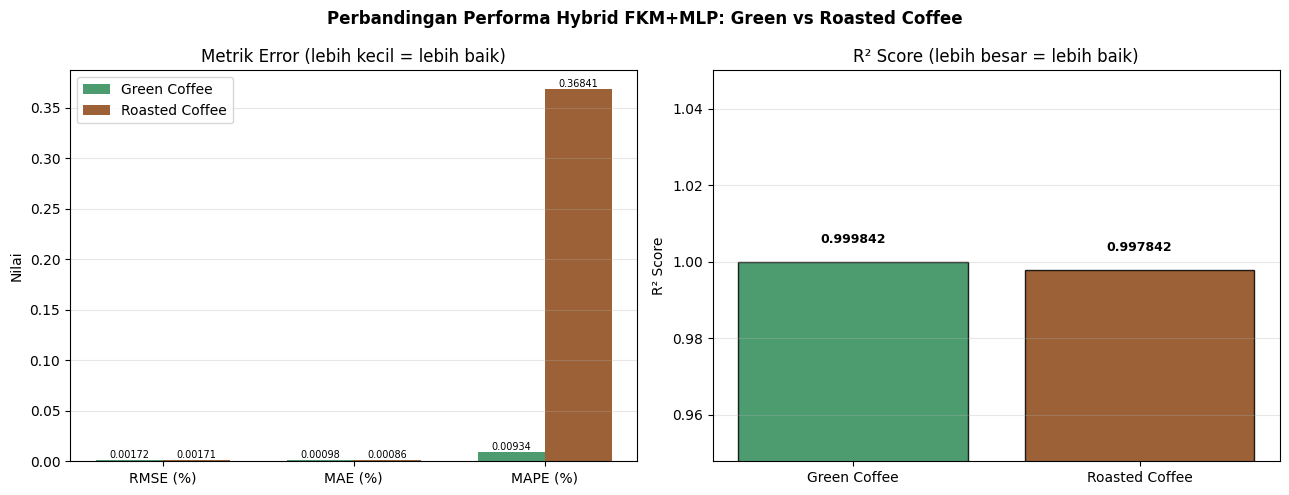

In [ ]:
# perbandingan metrik MLP: green vs roasted
df_mlp_compare = pd.DataFrame({
    'Dataset'   : ['Green Coffee', 'Roasted Coffee'],
    'R2 Score'  : [m_test['R2'],   m_roast_test['R2']],
    'RMSE (%)'  : [m_test['RMSE'], m_roast_test['RMSE']],
    'MAE (%)'   : [m_test['MAE'],  m_roast_test['MAE']],
    'MAPE (%)'  : [m_test['MAPE'], m_roast_test['MAPE']],
}).set_index('Dataset')

print('Perbandingan Performa MLP Hybrid: Green Coffee vs Roasted Coffee')
display(df_mlp_compare.round(6))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Perbandingan Performa Hybrid FKM+MLP: Green vs Roasted Coffee', fontsize=12, fontweight='bold')

datasets    = ['Green Coffee', 'Roasted Coffee']
colors      = ['seagreen', 'saddlebrown']
error_names = ['RMSE (%)', 'MAE (%)', 'MAPE (%)']
vals_green  = [m_test['RMSE'],       m_test['MAE'],       m_test['MAPE']]
vals_roast2 = [m_roast_test['RMSE'], m_roast_test['MAE'], m_roast_test['MAPE']]
x = np.arange(len(error_names))
w = 0.35

b1 = axes[0].bar(x - w/2, vals_green,  w, label='Green Coffee',   color='seagreen',     alpha=0.85)
b2 = axes[0].bar(x + w/2, vals_roast2, w, label='Roasted Coffee', color='saddlebrown',  alpha=0.85)
axes[0].set_title('Metrik Error (lebih kecil = lebih baik)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(error_names)
axes[0].set_ylabel('Nilai')
axes[0].legend()
axes[0].bar_label(b1, fmt='%.5f', fontsize=7)
axes[0].bar_label(b2, fmt='%.5f', fontsize=7)
axes[0].grid(axis='y', alpha=0.3)

r2_vals = [m_test['R2'], m_roast_test['R2']]
bars = axes[1].bar(datasets, r2_vals, color=colors, alpha=0.85, edgecolor='black')
axes[1].set_title('R² Score (lebih besar = lebih baik)')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim([min(r2_vals) - 0.05, 1.05])
for bar, v in zip(bars, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.005, f'{v:.6f}', ha='center', fontweight='bold', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('perbandingan_green_vs_roasted.png', dpi=150, bbox_inches='tight')
plt.show()


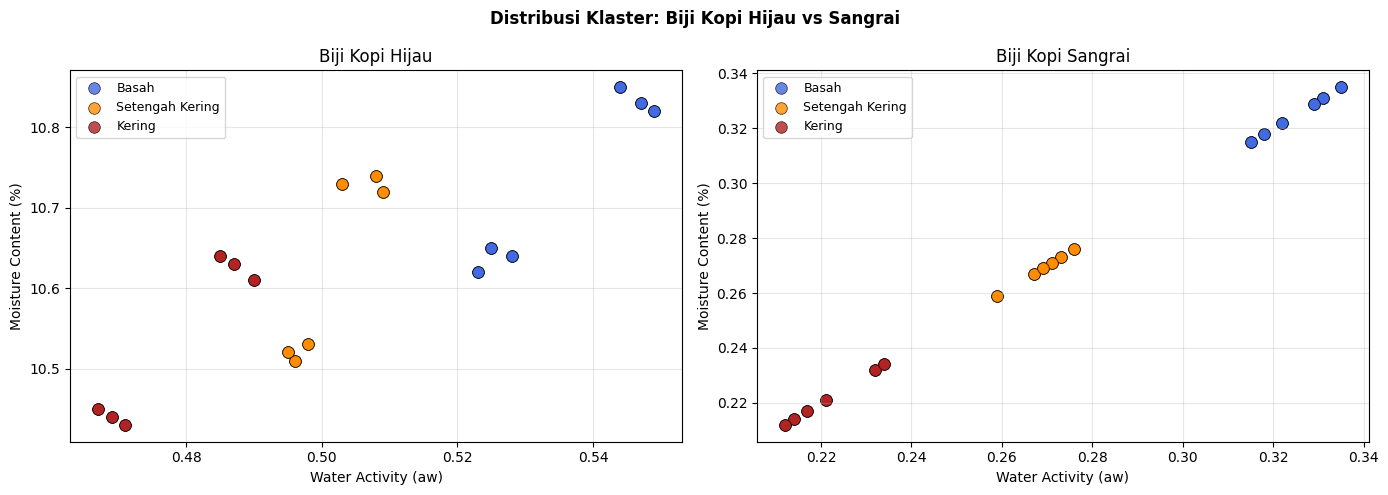

In [ ]:
# visualisasi klaster green vs roasted (scatter)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Klaster: Biji Kopi Hijau vs Sangrai', fontsize=12, fontweight='bold')

color_map_plot = {'Basah': 'royalblue', 'Setengah Kering': 'darkorange', 'Kering': 'firebrick'}

for ax, df_plot, labels, title, y_col in [
    (axes[0], df_green, cluster_labels_named, 'Biji Kopi Hijau',   TARGET),
    (axes[1], df_roast, labels_roast_named,   'Biji Kopi Sangrai', TARGET_ROAST)
]:
    for label, color in color_map_plot.items():
        mask = labels == label
        ax.scatter(
            df_plot.loc[mask, 'Water Activity (aw)'],
            df_plot.loc[mask, y_col],
            c=color, label=label, s=70, alpha=0.8, edgecolors='black', linewidths=0.5
        )
    ax.set_title(title)
    ax.set_xlabel('Water Activity (aw)')
    ax.set_ylabel('Moisture Content (%)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('klaster_green_vs_roasted.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Demo Sistem: Estimasi Kadar Air dari Data Baru

Fungsi `predict_drying_status` mensimulasikan sistem pengering cerdas:
1. Normalisasi input sensor
2. Fuzzifikasi nilai sensor
3. Tentukan klaster tingkat kekeringan via Fuzzy K-Means
4. Prediksi kadar air via MLP
5. Estimasi sisa waktu pengeringan

In [ ]:
def predict_drying_status(input_dict, verbose=True):
    df_in = pd.DataFrame([input_dict])
    X_in  = df_in[FEATURES].fillna(df_green[FEATURES].median())
    X_in_scaled = scaler_X.transform(X_in)

    wa_in = X_in_scaled[0, FEATURES.index('Water Activity (aw)')]
    bd_in = X_in_scaled[0, FEATURES.index('Bulk Density (kg/m\u00b3)')]
    mu_l_w, mu_m_w, mu_h_w = fuzzify(np.array([wa_in]))
    mu_l_b, mu_m_b, mu_h_b = fuzzify(np.array([bd_in]))

    idx_cf = [FEATURES.index(c) for c in CLUSTER_FEATURES]
    X_clust = np.column_stack([X_in_scaled[:, idx_cf], mu_l_w, mu_m_w, mu_h_w, mu_l_b, mu_m_b, mu_h_b])

    U_in       = fkm.get_membership(X_clust)
    cluster_in = fkm.predict(X_clust)[0]
    label_in   = cluster_name_map[cluster_in]
    ohe_in     = ohe.transform([[cluster_in]])

    X_mlp_in  = np.hstack([X_in_scaled, U_in, ohe_in])
    mc_pred   = scaler_y.inverse_transform(mlp_model.predict(X_mlp_in).reshape(-1, 1))[0, 0]

    target_mc   = 10.5
    drying_rate = 0.1
    time_est    = max(0, (mc_pred - target_mc) / drying_rate)

    result = {
        'moisture_content_pred'    : mc_pred,
        'cluster_label'            : label_in,
        'membership'               : {f'Klaster_{cluster_name_map[i]}': float(U_in[0, i]) for i in range(3)},
        'fuzzy_wa'                 : {'LOW': float(mu_l_w[0]), 'MEDIUM': float(mu_m_w[0]), 'HIGH': float(mu_h_w[0])},
        'estimated_hours_to_dry'   : time_est
    }

    if verbose:
        print('HASIL PREDIKSI SISTEM PENGERING CERDAS')
        print(f'  Kadar Air Prediksi    : {mc_pred:.4f} %')
        print(f'  Tingkat Kekeringan    : {label_in.upper()}')
        print(f'  Estimasi Waktu Kering : {time_est:.1f} jam')
        print('  Derajat Keanggotaan Fuzzy K-Means:')
        for k, v in result['membership'].items():
            bar = '\u2588' * int(v * 20)
            print(f'    {k:25s}: {v:.4f}  |{bar:<20}|')
        print('  Nilai Keanggotaan Fuzzy Water Activity:')
        for k, v in result['fuzzy_wa'].items():
            bar = '\u2588' * int(v * 20)
            print(f'    {k:10s}: {v:.4f}  |{bar:<20}|')

    return result

print('Fungsi predict_drying_status siap.')

Fungsi predict_drying_status siap.


In [ ]:
#uji dengan sampel pertama dataset
sample = df_green[FEATURES].iloc[0].to_dict()
result = predict_drying_status(sample)

HASIL PREDIKSI SISTEM PENGERING CERDAS
  Kadar Air Prediksi    : 10.8300 %
  Tingkat Kekeringan    : BASAH
  Estimasi Waktu Kering : 3.3 jam
  Derajat Keanggotaan Fuzzy K-Means:
    Klaster_Setengah Kering  : 0.3869  |███████             |
    Klaster_Basah            : 0.4568  |█████████           |
    Klaster_Kering           : 0.1563  |███                 |
  Nilai Keanggotaan Fuzzy Water Activity:
    LOW       : 0.0000  |                    |
    MEDIUM    : 0.0488  |                    |
    HIGH      : 0.9512  |███████████████████ |


In [ ]:
print('SIMULASI 3 SKENARIO KONDISI BIJI KOPI')
print()

scenarios = [
    ('Skenario 1 - Biji Baru Dipanen (Basah)',      df_green[FEATURES][cluster_labels_named == 'Basah'].mean().to_dict()),
    ('Skenario 2 - Proses Setengah Jalan',          df_green[FEATURES][cluster_labels_named == 'Setengah Kering'].mean().to_dict()),
    ('Skenario 3 - Hampir Kering',                  df_green[FEATURES][cluster_labels_named == 'Kering'].mean().to_dict()),
]

for nama, sc in scenarios:
    print(f'  {nama}')
    res = predict_drying_status(sc, verbose=False)
    print(f'    Kadar Air     : {res["moisture_content_pred"]:.4f} %')
    print(f'    Kekeringan    : {res["cluster_label"]}')
    print(f'    Sisa Waktu    : {res["estimated_hours_to_dry"]:.1f} jam')
    print()

SIMULASI 3 SKENARIO KONDISI BIJI KOPI

  Skenario 1 - Biji Baru Dipanen (Basah)
    Kadar Air     : 10.7108 %
    Kekeringan    : Basah
    Sisa Waktu    : 2.1 jam

  Skenario 2 - Proses Setengah Jalan
    Kadar Air     : 10.6552 %
    Kekeringan    : Setengah Kering
    Sisa Waktu    : 1.6 jam

  Skenario 3 - Hampir Kering
    Kadar Air     : 10.5295 %
    Kekeringan    : Kering
    Sisa Waktu    : 0.3 jam



## 11. Ringkasan Akhir

In [ ]:
print('RINGKASAN HASIL SISTEM HYBRID FUZZY K-MEANS + MLP')
print()
print('DATASET')
print(f'  Biji Kopi Hijau  : {df_green.shape[0]} sampel, {df_green.shape[1]} fitur')
print(f'  Biji Kopi Sangrai: {df_roast.shape[0]} sampel, {df_roast.shape[1]} fitur')
print()
print('TAHAP 1 - FUZZIFIKASI')
print(f'  Metode : Triangular Membership Function')
print(f'  Output : {len(FEATURES)*3} nilai keanggotaan ({len(FEATURES)} fitur x 3 kategori)')
print()
print('TAHAP 2 - FUZZY K-MEANS')
print(f'  Jumlah klaster : 3 (Basah / Setengah Kering / Kering)')
print(f'  Iterasi        : {len(fkm.history_)}')
for label in ['Basah', 'Setengah Kering', 'Kering']:
    n = np.sum(cluster_labels_named == label)
    print(f'  {label:20s}: {n} sampel ({n/len(cluster_labels_named)*100:.1f}%)')
print()
print('TAHAP 3 - MLP REGRESSOR')
print(f'  Arsitektur : Input({X_mlp.shape[1]}) -> 64 -> 32 -> 16 -> Output(1)')
print(f'  Optimizer  : Adam (lr=0.001, adaptive)')
print(f'  Iterasi    : {mlp_model.n_iter_}')
print(f'  Split Data : 70% train / 15% validasi / 15% test')
print()
print('EVALUASI TEST SET')
print(f'  RMSE : {m_test["RMSE"]:.6f} %')
print(f'  MAE  : {m_test["MAE"]:.6f} %')
print(f'  MAPE : {m_test["MAPE"]:.4f} %')
print(f'  R2   : {m_test["R2"]:.4f}')
print()
print('PENINGKATAN VS BASELINE (MLP Biasa)')
print(f'  RMSE : {rmse_bl:.6f} -> {m_test["RMSE"]:.6f} ({(rmse_bl - m_test["RMSE"]) / rmse_bl * 100:+.2f}%)')
print(f'  R2   : {r2_bl:.4f}  -> {m_test["R2"]:.4f}  ({m_test["R2"] - r2_bl:+.4f})')

RINGKASAN HASIL SISTEM HYBRID FUZZY K-MEANS + MLP

DATASET
  Biji Kopi Hijau  : 54 sampel, 15 fitur
  Biji Kopi Sangrai: 54 sampel, 13 fitur

TAHAP 1 - FUZZIFIKASI
  Metode : Triangular Membership Function
  Output : 33 nilai keanggotaan (11 fitur x 3 kategori)

TAHAP 2 - FUZZY K-MEANS
  Jumlah klaster : 3 (Basah / Setengah Kering / Kering)
  Iterasi        : 23
  Basah               : 18 sampel (33.3%)
  Setengah Kering     : 18 sampel (33.3%)
  Kering              : 18 sampel (33.3%)

TAHAP 3 - MLP REGRESSOR
  Arsitektur : Input(17) -> 64 -> 32 -> 16 -> Output(1)
  Optimizer  : Adam (lr=0.001, adaptive)
  Iterasi    : 254
  Split Data : 70% train / 15% validasi / 15% test

EVALUASI TEST SET
  RMSE : 0.001722 %
  MAE  : 0.000977 %
  MAPE : 0.0093 %
  R2   : 0.9998

PENINGKATAN VS BASELINE (MLP Biasa)
  RMSE : 0.007351 -> 0.001722 (+76.58%)
  R2   : 0.9971  -> 0.9998  (+0.0027)
